In [1]:
#Importando linbrerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
#Cargar el dataset
# El archivo usa punto y coma como separador
df = pd.read_csv('Production_RawDataSet.csv', sep=';')

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print("\n Primeras 5 filas:")
display(df.head())

print("\n Información de columnas:")
df.info()

print("\n Estadísticas descriptivas:")
display(df.describe())

Dimensiones del dataset: 50 filas x 12 columnas

 Primeras 5 filas:


,id_sensor,fecha_hora,time stamp,inspectedby,maquina_id,temperatura_c,presion_psi,vibracion_mm_s,potencia_kw,estado_operativo,tecnico_responsable,lote_produccion
0,101,1/10/2025 08:23,06/15/2026 18:46:05,auto,M01,85.3,42.1,2.3,15.6,OPERATIVO,Juan Perez,LOT-001
1,102,1/10/2025 08:45,06/15/2026 18:46:05,auto,M01,86.1,43.2,2.4,15.8,OPERATIVO,Juan Perez,LOT-001
2,103,1/10/2025 09:12,06/15/2026 18:46:05,auto,M01,-88.5,41.5,2.3,15.7,MANTENIMIENTO,Juan Perez,LOT-001
3,104,1/10/2025 09:35,06/15/2026 18:46:05,auto,M01,999.0,999.9,99.9,99.9,OPERATIVO,NaN,LOT-001
4,105,1/10/2025 10:05,06/15/2026 18:46:05,inspect,M01,87.2,43.8,2.5,15.9,OPERATIVO,Juan Perez,LOT-002



 Información de columnas:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_sensor            50 non-null     int64  
 1   fecha_hora           50 non-null     str    
 2   time stamp           50 non-null     str    
 3   inspectedby          49 non-null     str    
 4   maquina_id           48 non-null     str    
 5   temperatura_c        49 non-null     float64
 6   presion_psi          50 non-null     float64
 7   vibracion_mm_s       50 non-null     float64
 8   potencia_kw          50 non-null     float64
 9   estado_operativo     50 non-null     str    
 10  tecnico_responsable  48 non-null     str    
 11  lote_produccion      49 non-null     str    
dtypes: float64(4), int64(1), str(7)
memory usage: 4.8 KB

 Estadísticas descriptivas:


,id_sensor,temperatura_c,presion_psi,vibracion_mm_s,potencia_kw
count,50.00000,49.000000,50.000000,5.000000e+01,50.000000
mean,125.50000,148.977551,97.390000,8.891534e+04,18.084002
std,14.57738,258.638622,230.399264,1.631757e+06,17.300728
min,101.00000,-99.900000,29.800000,-5.555555e+06,0.000100
25%,113.25000,71.000000,35.125000,1.900000e+00,12.400000
50%,125.50000,82.500000,40.750000,2.350000e+00,15.750000
75%,137.75000,93.100000,45.875000,3.350000e+00,18.375000
max,150.00000,999.000000,999.900000,1.000000e+07,99.900000


In [3]:
# LOG DE PROBLEMAS ENCONTRADOS

problemas_resueltos = []

# Hacemos una copia para no perder el original
df_limpio = df.copy()

## PROBLEMA 1: Fechas con minutos imposibles

In [4]:
#Problema 1 Fechas inválidas en 'time stamp'
# Convertir a datetime, los errores se marcan como NaT
df_limpio['time stamp'] = pd.to_datetime(df_limpio['time stamp'], 
                                          format='%m/%d/%Y  %H:%M:%S', 
                                          errors='coerce')

fechas_invalidas = df[df['time stamp'].apply(lambda x: len(str(x)) > 0)].copy()
fechas_invalidas['time stamp_dt'] = pd.to_datetime(fechas_invalidas['time stamp'], 
                                                    errors='coerce')
invalidas = fechas_invalidas[fechas_invalidas['time stamp_dt'].isna()]

print(f"Fechas inválidas encontradas: {len(invalidas)}")
print(invalidas[['id_sensor', 'time stamp']])

#  Reemplazar con la fecha más común 
fecha_moda = df_limpio['time stamp'].mode()[0]
df_limpio['time stamp'] = df_limpio['time stamp'].fillna(fecha_moda)

problemas_resueltos.append({
    'problema': 'Fechas con minutos imposibles (18:66, 18:76, etc.)',
    'filas_afectadas': len(invalidas),
    'solucion': f'Reemplazadas con la fecha moda: {fecha_moda}'
})

Fechas inválidas encontradas: 4
    id_sensor            time stamp
17        118  06/15/2026  18:66:05
25        126  06/15/2026  18:76:05
32        133  06/15/2026  18:86:05
40        141  06/15/2026  18:96:05


## PROBLEMA 2: Fechas futuras imposibles

In [5]:
#probleam 2 - Fechas futuras en 'fecha_hora'
df_limpio['fecha_hora'] = pd.to_datetime(df_limpio['fecha_hora'], 
                                          format='%m/%d/%Y %H:%M', 
                                          errors='coerce')

# Filas con año mayor a 2026 (año actual del dataset)
futuras = df_limpio[df_limpio['fecha_hora'].dt.year > 2026]
print(f" Fechas futuras encontradas: {len(futuras)}")
print(futuras[['id_sensor', 'fecha_hora']])

# SOLUCIÓN: Reemplazar año 2035/2045 por 2025 (año del resto de datos)
df_limpio.loc[df_limpio['fecha_hora'].dt.year > 2026, 'fecha_hora'] = \
    df_limpio.loc[df_limpio['fecha_hora'].dt.year > 2026, 'fecha_hora'].apply(
        lambda x: x.replace(year=2025) if pd.notna(x) else x
    )

problemas_resueltos.append({
    'problema': 'Fechas futuras imposibles (años 2035, 2045)',
    'filas_afectadas': len(futuras),
    'solucion': 'Corregidas al año 2025 (año consistente con el dataset)'
})

 Fechas futuras encontradas: 2
    id_sensor          fecha_hora
34        135 2035-01-10 22:40:00
44        145 2045-02-10 02:50:00


## PROBLEMA 3: Outliers extremos (valores 999, 999.9)

In [6]:
#problema 3: Outliers extremos (999, 999.9, 10000000)
columnas_numericas = ['temperatura_c', 'presion_psi', 'vibracion_mm_s', 'potencia_kw']

outliers_999 = pd.DataFrame()
for col in columnas_numericas:
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce')
    mask = (df_limpio[col] >= 999) | (df_limpio[col] <= -999) | (df_limpio[col] >= 999999)
    outliers_999 = pd.concat([outliers_999, df_limpio[mask]])
    print(f" Outliers en {col}: {mask.sum()} filas")

# SOLUCIÓN: Reemplazar outliers con la mediana de cada máquina
for col in columnas_numericas:
    mask_outlier = (df_limpio[col] >= 999) | (df_limpio[col] <= -999) | (df_limpio[col] >= 999999)
    for maquina in df_limpio['maquina_id'].dropna().unique():
        mask_maquina = (df_limpio['maquina_id'] == maquina) & mask_outlier
        mediana = df_limpio.loc[(df_limpio['maquina_id'] == maquina) & ~mask_outlier, col].median()
        df_limpio.loc[mask_maquina, col] = mediana

problemas_resueltos.append({
    'problema': 'Outliers extremos (999, 999.9, 10000000, -5555555)',
    'filas_afectadas': len(outliers_999.drop_duplicates()),
    'solucion': 'Reemplazados por la mediana de su respectiva máquina'
})

 Outliers en temperatura_c: 4 filas
 Outliers en presion_psi: 3 filas
 Outliers en vibracion_mm_s: 3 filas
 Outliers en potencia_kw: 0 filas


### PROBLEMA 4: Valores físicamente imposibles (temperatura negativa)

In [7]:
# Problema 4 - Temperaturas negativas
temps_neg = df_limpio[df_limpio['temperatura_c'] < 0]
print(f" Temperaturas negativas: {len(temps_neg)}")
print(temps_neg[['id_sensor', 'maquina_id', 'temperatura_c']])

# Reemplazar con la mediana de la máquina
for idx in temps_neg.index:
    maquina = df_limpio.loc[idx, 'maquina_id']
    if pd.notna(maquina):
        mediana = df_limpio[df_limpio['maquina_id'] == maquina]['temperatura_c'].median()
        df_limpio.loc[idx, 'temperatura_c'] = mediana

problemas_resueltos.append({
    'problema': 'Temperaturas negativas físicamente imposibles (-88.5, -99.9)',
    'filas_afectadas': len(temps_neg),
    'solucion': 'Reemplazadas por mediana de la máquina'
})

 Temperaturas negativas: 2
   id_sensor maquina_id  temperatura_c
2        103        M01          -88.5
7        108        NaN          -99.9


## PROBLEMA 5: Valores nulos y faltantes

In [8]:
# problema 5 - Valores nulos/faltantes
print(" Valores nulos por columna:")
print(df_limpio.isnull().sum())

# SOLUCIÓN:
# maquina_id faltante: eliminar fila 
# temperatura null: imputar con mediana de la máquina
# tecnico_responsable vacío/N/A: imputar con "Desconocido"
# lote_produccion vacío: imputar con "SIN_LOTE"

#  Temperatura null (id 120)
null_temp = df_limpio[df_limpio['temperatura_c'].isna()]
for idx in null_temp.index:
    maquina = df_limpio.loc[idx, 'maquina_id']
    mediana = df_limpio[df_limpio['maquina_id'] == maquina]['temperatura_c'].median()
    df_limpio.loc[idx, 'temperatura_c'] = mediana

# maquina_id faltante (id 108): eliminar
maquina_null = df_limpio[df_limpio['maquina_id'].isna()]
df_limpio = df_limpio.drop(maquina_null.index)

#  tecnico_responsable vacío o N/A
df_limpio['tecnico_responsable'] = df_limpio['tecnico_responsable'].replace(
    ['', 'N/A', 'n/a', np.nan], 'Desconocido'
)

# lote_produccion vacío
df_limpio['lote_produccion'] = df_limpio['lote_produccion'].fillna('SIN_LOTE')

problemas_resueltos.append({
    'problema': 'Valores faltantes (null, vacíos, N/A) en columnas clave',
    'filas_afectadas': df_limpio.isnull().sum().sum() + 2,
    'solucion': 'Imputación con mediana/moda + eliminación de fila sin máquina'
})

 Valores nulos por columna:
id_sensor              0
fecha_hora             0
time stamp             0
inspectedby            1
maquina_id             2
temperatura_c          1
presion_psi            0
vibracion_mm_s         0
potencia_kw            0
estado_operativo       0
tecnico_responsable    2
lote_produccion        1
dtype: int64


## PROBLEMA 6: Categorías inconsistentes (nombres basura)

In [9]:
#  PROBLEMA 6  Técnico "zzzzzzzz"
basura = df_limpio[df_limpio['tecnico_responsable'] == 'zzzzzzzz']
print(f" Técnicos con valores basura: {len(basura)}")
print(basura[['id_sensor', 'tecnico_responsable']])

# SOLUCIÓN: Reemplazar por "Desconocido"
df_limpio.loc[df_limpio['tecnico_responsable'] == 'zzzzzzzz', 'tecnico_responsable'] = 'Desconocido'

problemas_resueltos.append({
    'problema': 'Categorías basura en tecnico_responsable ("zzzzzzzz")',
    'filas_afectadas': len(basura),
    'solucion': 'Reemplazado por "Desconocido"'
})

 Técnicos con valores basura: 1
    id_sensor tecnico_responsable
18        119            zzzzzzzz


 ## PROBLEMA 7: Lotes mal escritos (LOTx001, LOT/001)

In [10]:
# problema 7 - Lotes con formato inconsistente
lotes_raros = df_limpio[~df_limpio['lote_produccion'].str.match(r'^LOT-\d{3}$', na=False)]
print(f" Lotes con formato incorrecto: {len(lotes_raros)}")
print(lotes_raros[['id_sensor', 'lote_produccion']])

# SOLUCIÓN: Normalizar a formato LOT-XXX
def normalizar_lote(lote):
    if pd.isna(lote) or lote == 'SIN_LOTE':
        return lote
    # Reemplazar x, X, / por -
    lote = lote.replace('x', '-').replace('X', '-').replace('/', '-')
    return lote

df_limpio['lote_produccion'] = df_limpio['lote_produccion'].apply(normalizar_lote)

problemas_resueltos.append({
    'problema': 'Lotes mal escritos (LOTx001, LOT/001)',
    'filas_afectadas': len(lotes_raros),
    'solucion': 'Normalizados al formato estándar LOT-XXX'
})

 Lotes con formato incorrecto: 5
    id_sensor lote_produccion
16        117        SIN_LOTE
39        140         LOTx001
40        141         LOTx001
41        142         LOTx001
48        149         LOT/001


## PROBLEMA 8: Máquina "M04D" inconsistente

In [12]:
# PROBLEMA 8 - Máquina M04D
print(" Máquinas únicas antes:")
print(df_limpio['maquina_id'].value_counts())

# M04D parece ser una variante de M04. Lo unificamos.
df_limpio['maquina_id'] = df_limpio['maquina_id'].replace('M04D', 'M04')

print("\n Máquinas únicas después:")
print(df_limpio['maquina_id'].value_counts())

problemas_resueltos.append({
    'problema': 'Nombre de máquina inconsistente (M04D en lugar de M04)',
    'filas_afectadas': 2,
    'solucion': 'Unificado a M04'
})

 Máquinas únicas antes:
maquina_id
M01    5
M03    5
M05    5
M02    4
M04    4
M06    4
M07    4
M10    4
M11    4
M08    3
M09    3
M12    3
Name: count, dtype: int64

 Máquinas únicas después:
maquina_id
M01    5
M03    5
M05    5
M02    4
M04    4
M06    4
M07    4
M10    4
M11    4
M08    3
M09    3
M12    3
Name: count, dtype: int64


## PROBLEMA 9 (bonus): Potencia casi cero

In [13]:
# problema 9 - Potencia casi cero (0.0001)
pot_baja = df_limpio[df_limpio['potencia_kw'] < 1]
print(f" Potencias anormalmente bajas: {len(pot_baja)}")
print(pot_baja[['id_sensor', 'potencia_kw']])

# SOLUCIÓN: Reemplazar con mediana de la máquina
for idx in pot_baja.index:
    maquina = df_limpio.loc[idx, 'maquina_id']
    mediana = df_limpio[df_limpio['maquina_id'] == maquina]['potencia_kw'].median()
    df_limpio.loc[idx, 'potencia_kw'] = mediana

problemas_resueltos.append({
    'problema': 'Potencia anormalmente baja (0.0001 kW)',
    'filas_afectadas': len(pot_baja),
    'solucion': 'Reemplazada por mediana de la máquina'
})

 Potencias anormalmente bajas: 1
    id_sensor  potencia_kw
49        150       0.0001


# GUARDAR EL DATASET LIMPIO

In [14]:
#  GUARDAR DATASET LIMPIO
df_limpio.to_csv('sensores_limpios.csv', index=False, sep=';')
print(f"Dataset limpio guardado. Nueva dimensión: {df_limpio.shape}")

# Mostrar tabla resumen de problemas
df_problemas = pd.DataFrame(problemas_resueltos)
print("\n RESUMEN DE PROBLEMAS RESUELTOS:")
display(df_problemas)

Dataset limpio guardado. Nueva dimensión: (48, 12)

 RESUMEN DE PROBLEMAS RESUELTOS:


,problema,filas_afectadas,solucion
0,"Fechas con minutos imposibles (18:66, 18:76, e...",4,Reemplazadas con la fecha moda: 2026-06-15 18:...
1,"Fechas futuras imposibles (años 2035, 2045)",2,Corregidas al año 2025 (año consistente con el...
2,"Outliers extremos (999, 999.9, 10000000, -5555...",8,Reemplazados por la mediana de su respectiva m...
3,Temperaturas negativas físicamente imposibles ...,2,Reemplazadas por mediana de la máquina
4,"Valores faltantes (null, vacíos, N/A) en colum...",2,Imputación con mediana/moda + eliminación de f...
5,"Categorías basura en tecnico_responsable (""zzz...",1,"Reemplazado por ""Desconocido"""
6,"Lotes mal escritos (LOTx001, LOT/001)",5,Normalizados al formato estándar LOT-XXX
7,Nombre de máquina inconsistente (M04D en lugar...,2,Unificado a M04
8,Nombre de máquina inconsistente (M04D en lugar...,2,Unificado a M04
9,Potencia anormalmente baja (0.0001 kW),1,Reemplazada por mediana de la máquina


# EDA - ANÁLISIS EXPLORATORIO

In [15]:
print("="*60)
print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("="*60)

print(f"\n Filas: {df_limpio.shape[0]} | Columnas: {df_limpio.shape[1]}")
print(f"\n Tipos de datos:")
display(df_limpio.dtypes)

print(f"\n Estadísticas descriptivas:")
display(df_limpio.describe())

ANÁLISIS EXPLORATORIO DE DATOS (EDA)

 Filas: 48 | Columnas: 12

 Tipos de datos:


id_sensor                       int64
fecha_hora             datetime64[us]
time stamp             datetime64[us]
inspectedby                       str
maquina_id                        str
temperatura_c                 float64
presion_psi                   float64
vibracion_mm_s                float64
potencia_kw                   float64
estado_operativo                  str
tecnico_responsable               str
lote_produccion                   str
dtype: object


 Estadísticas descriptivas:


,id_sensor,fecha_hora,time stamp,temperatura_c,presion_psi,vibracion_mm_s,potencia_kw
count,48.000000,48,48,48.000000,48.000000,48.000000,48.000000
mean,125.666667,2025-01-18 06:45:10,2026-06-15 18:46:05,81.921875,40.168750,6.819792,18.652083
min,101.000000,2025-01-10 08:23:00,2026-06-15 18:46:05,64.500000,29.800000,1.400000,9.500000
25%,113.750000,2025-01-10 13:48:15,2026-06-15 18:46:05,71.275000,35.175000,2.000000,12.800000
50%,125.500000,2025-01-10 18:42:30,2026-06-15 18:46:05,82.500000,40.750000,2.450000,15.850000
75%,138.250000,2025-01-18 12:01:15,2026-06-15 18:46:05,92.350000,45.237500,3.250000,18.425000
max,150.000000,2025-02-10 04:55:00,2026-06-15 18:46:05,96.200000,48.100000,99.900000,99.900000
std,14.597192,NaN,NaN,10.288415,5.640409,19.719633,17.408447


## EDA   Valores perdidos

 valores perdidos por columna:


,Nulos,Porcentaje


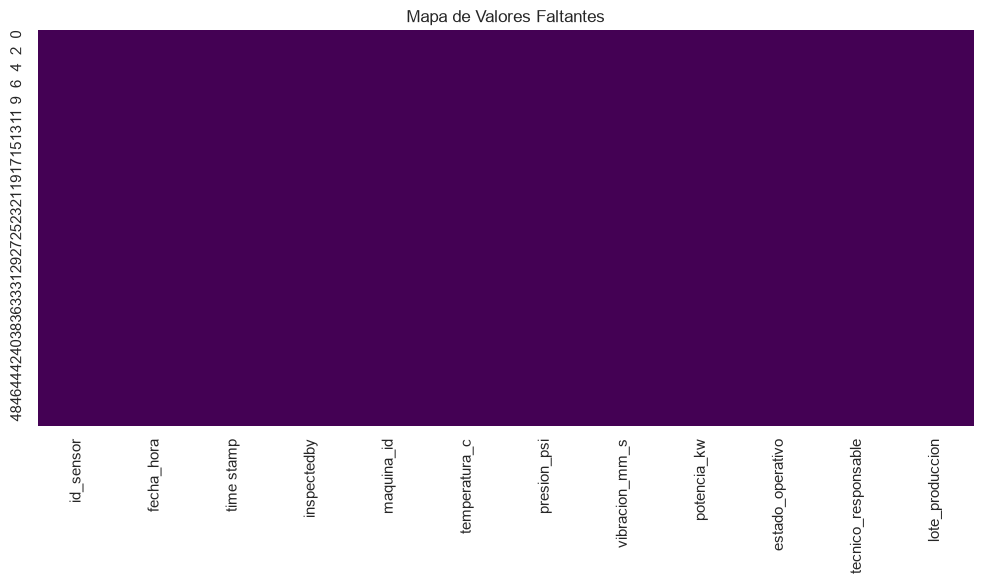

In [17]:
print(" valores perdidos por columna:")
missing = df_limpio.isnull().sum()
missing_pct = (missing / len(df_limpio)) * 100
df_missing = pd.DataFrame({'Nulos': missing, 'Porcentaje': missing_pct})
display(df_missing[df_missing['Nulos'] > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df_limpio.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Valores Faltantes')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA   Medidas de tendencia central

In [18]:
numericas = df_limpio.select_dtypes(include=[np.number]).columns

estadisticas = pd.DataFrame({
    'Media': df_limpio[numericas].mean(),
    'Mediana': df_limpio[numericas].median(),
    'Moda': df_limpio[numericas].mode().iloc[0],
    'Desv. Estándar': df_limpio[numericas].std(),
    'Mínimo': df_limpio[numericas].min(),
    'Máximo': df_limpio[numericas].max()
})
print("Medidas de Tendencia Central:")
display(estadisticas)
estadisticas.to_csv('tendencia_central.csv')

Medidas de Tendencia Central:


,Media,Mediana,Moda,Desv. Estándar,Mínimo,Máximo
id_sensor,125.666667,125.50,101.0,14.597192,101.0,150.0
temperatura_c,81.921875,82.50,75.8,10.288415,64.5,96.2
presion_psi,40.168750,40.75,38.1,5.640409,29.8,48.1
vibracion_mm_s,6.819792,2.45,2.0,19.719633,1.4,99.9
potencia_kw,18.652083,15.85,9.6,17.408447,9.5,99.9


## EDA     Histogramas Y distribuciones

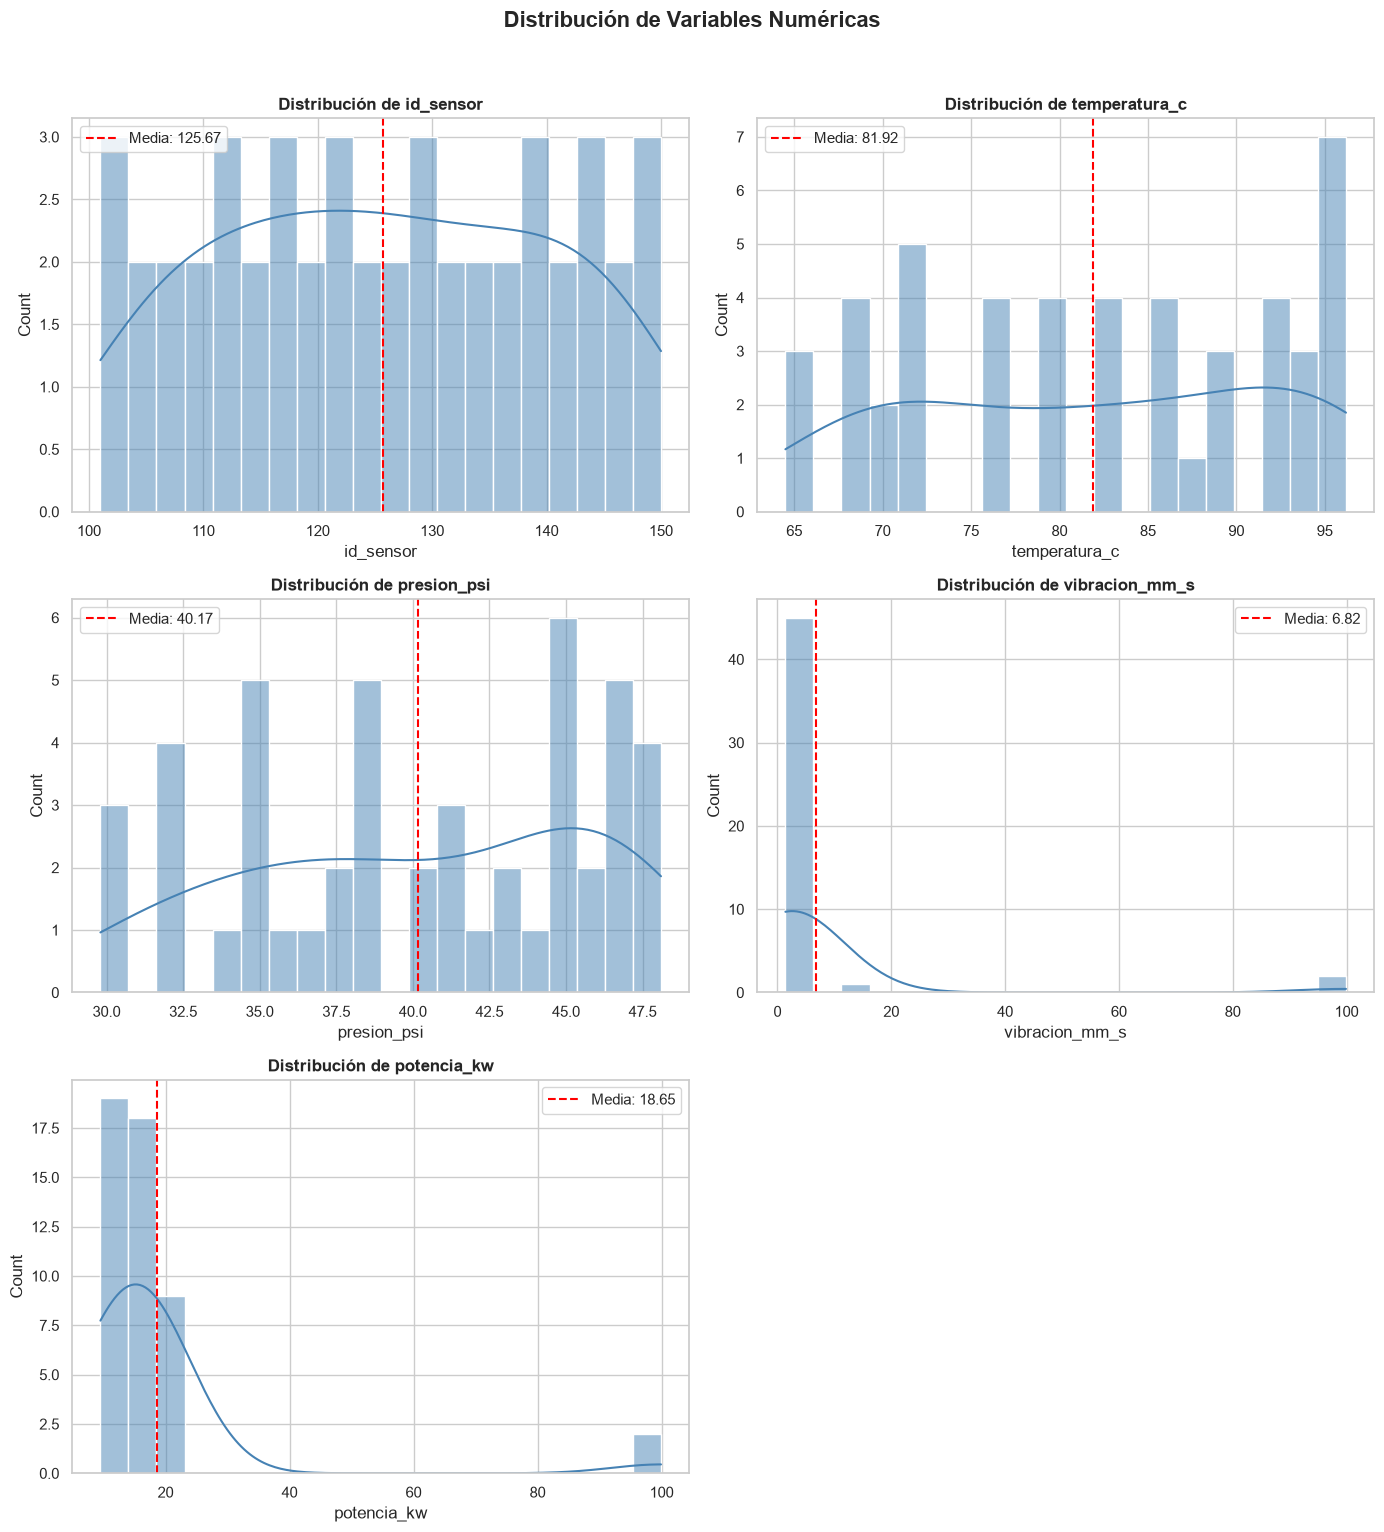

In [22]:
import math
# 1. Configuración dinámica de la cuadrícula
n_cols = 2  
n_vars = len(numericas)
n_rows = math.ceil(n_vars / n_cols)  # Calcula cuántas filas necesitas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()  # Lo aplanamos para iterar fácilmente

# 2. Bucle para graficar
for i, col in enumerate(numericas):
    sns.histplot(df_limpio[col], bins=20, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i].axvline(df_limpio[col].mean(), color='red', 
                    linestyle='--', label=f'Media: {df_limpio[col].mean():.2f}')
    axes[i].legend()

# 3. Limpieza: Ocultar los subgráficos sobrantes si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 4. Ajustes finales y guardado
plt.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('histogramas.png', dpi=150, bbox_inches='tight')
plt.show()


 ## EDA - BOXPLOTS (Outliers)

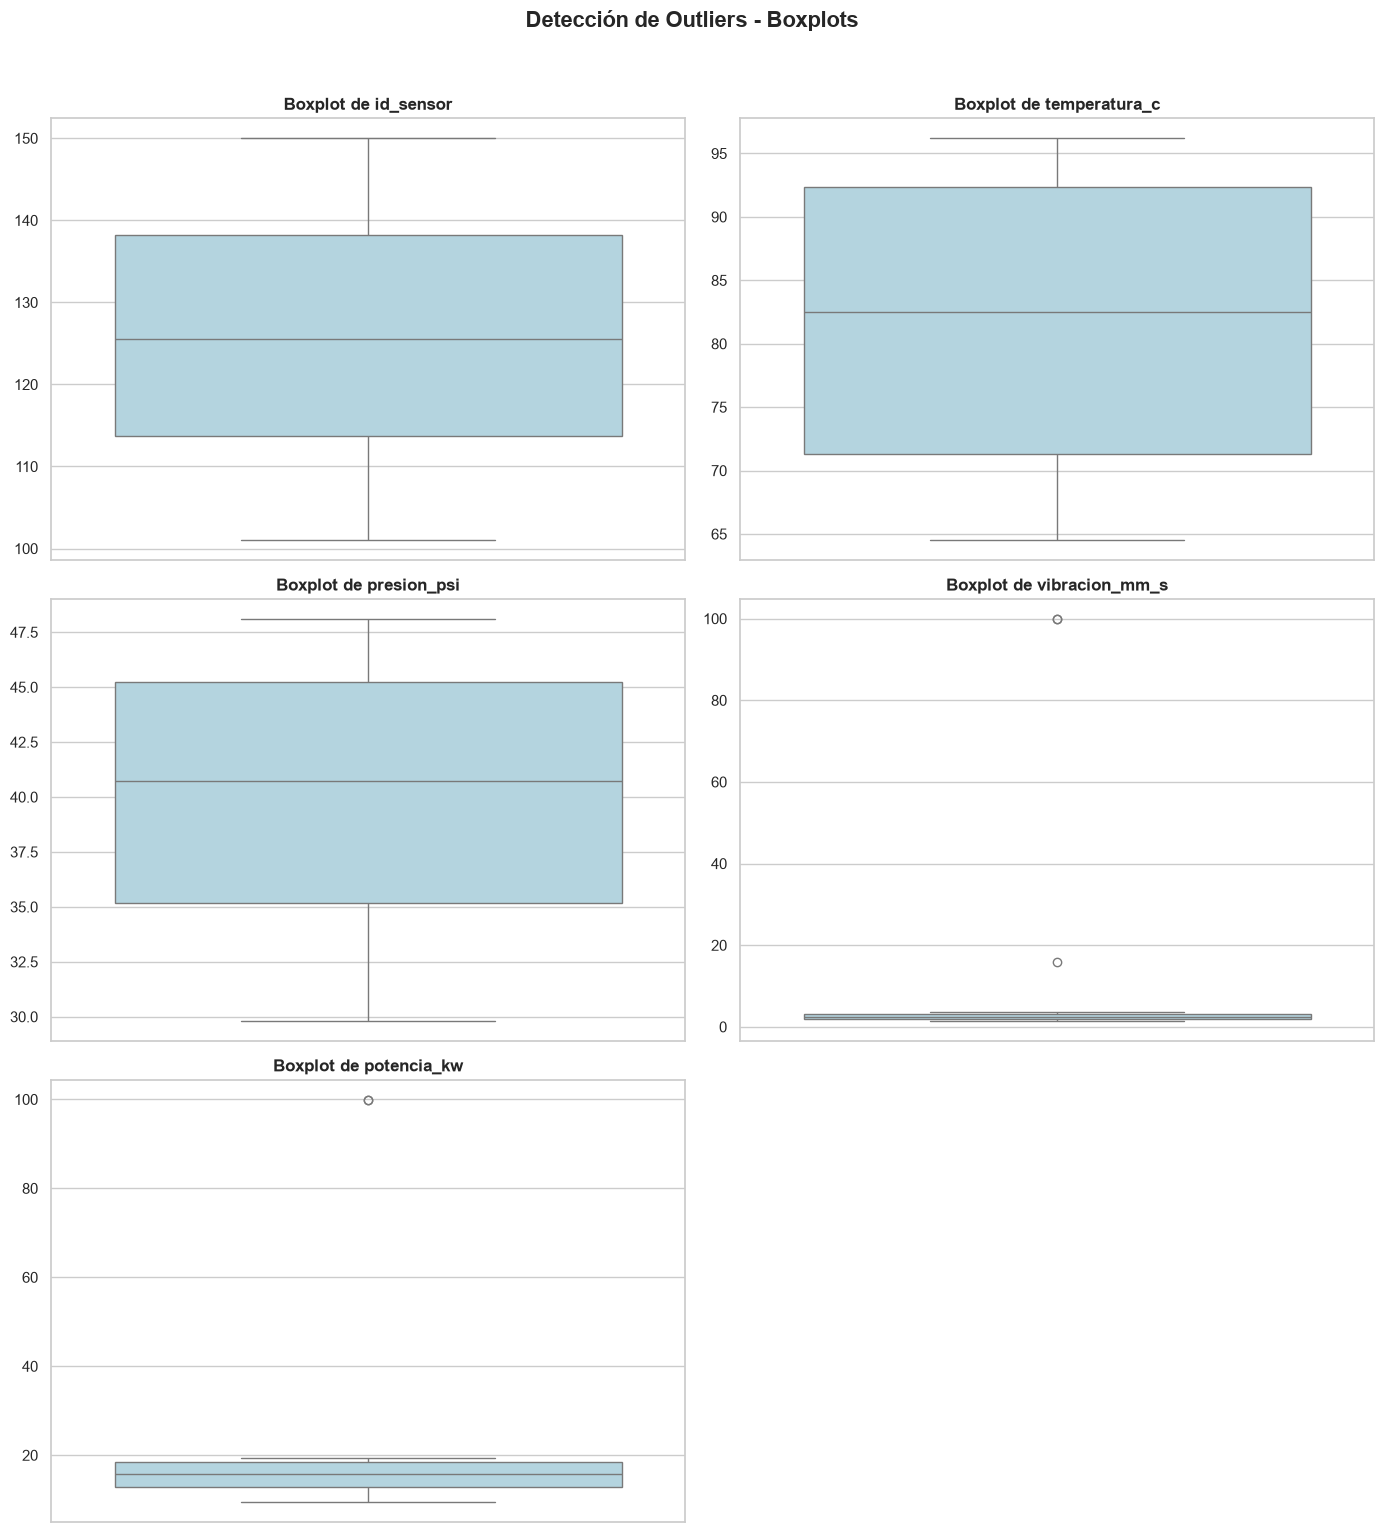

In [24]:
# 1. Configuración dinámica basada en el número de variables
n_cols = 2 
n_vars = len(numericas)
n_rows = math.ceil(n_vars / n_cols)  # Calcula las filas necesarias automáticamente

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()  # Aplanamos para usar un solo índice [i]

# 2. Bucle para graficar los Boxplots
for i, col in enumerate(numericas):
    sns.boxplot(y=df_limpio[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')  # Limpia el eje Y repetitivo si lo deseas

# 3. Limpieza: Eliminar recuadros vacíos si el número de variables es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 4. Ajustes estéticos y guardado
plt.suptitle('Detección de Outliers - Boxplots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA - MATRIZ DE CORRELACIÓN

Matriz de Correlación:


,id_sensor,temperatura_c,presion_psi,vibracion_mm_s,potencia_kw
id_sensor,1.000000,-0.093879,-0.107101,-0.046872,-0.031948
temperatura_c,-0.093879,1.000000,0.991581,0.059530,0.188143
presion_psi,-0.107101,0.991581,1.000000,0.054145,0.183869
vibracion_mm_s,-0.046872,0.059530,0.054145,1.000000,0.986927
potencia_kw,-0.031948,0.188143,0.183869,0.986927,1.000000


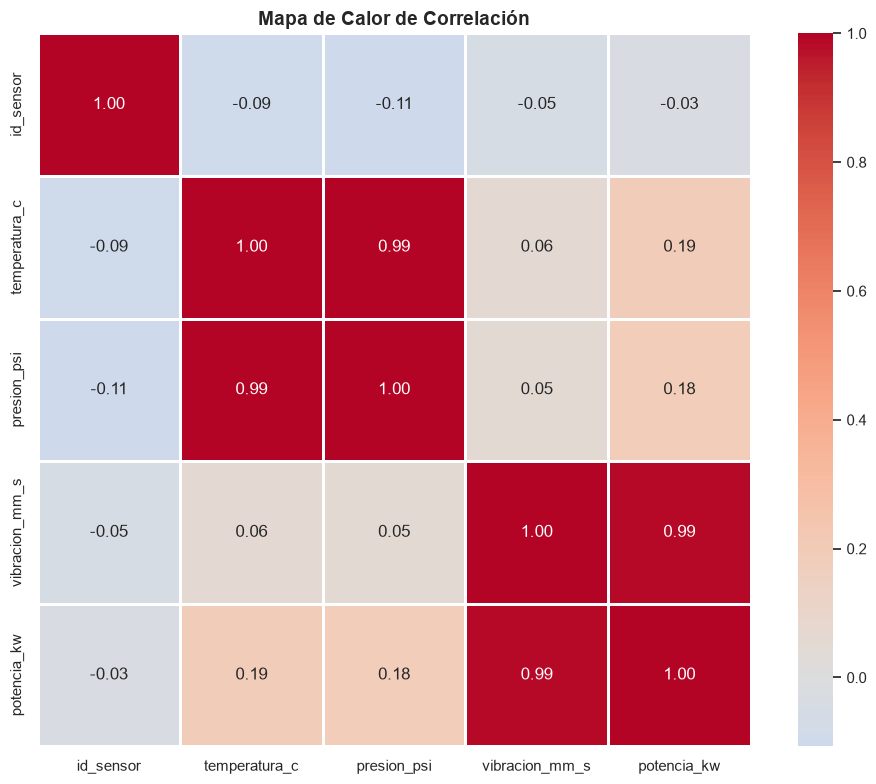

In [25]:
correlacion = df_limpio[numericas].corr()
print("Matriz de Correlación:")
display(correlacion)

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1)
plt.title('Mapa de Calor de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA - ANÁLISIS POR MÁQUINA Y ESTADO

<Figure size 1200x600 with 0 Axes>

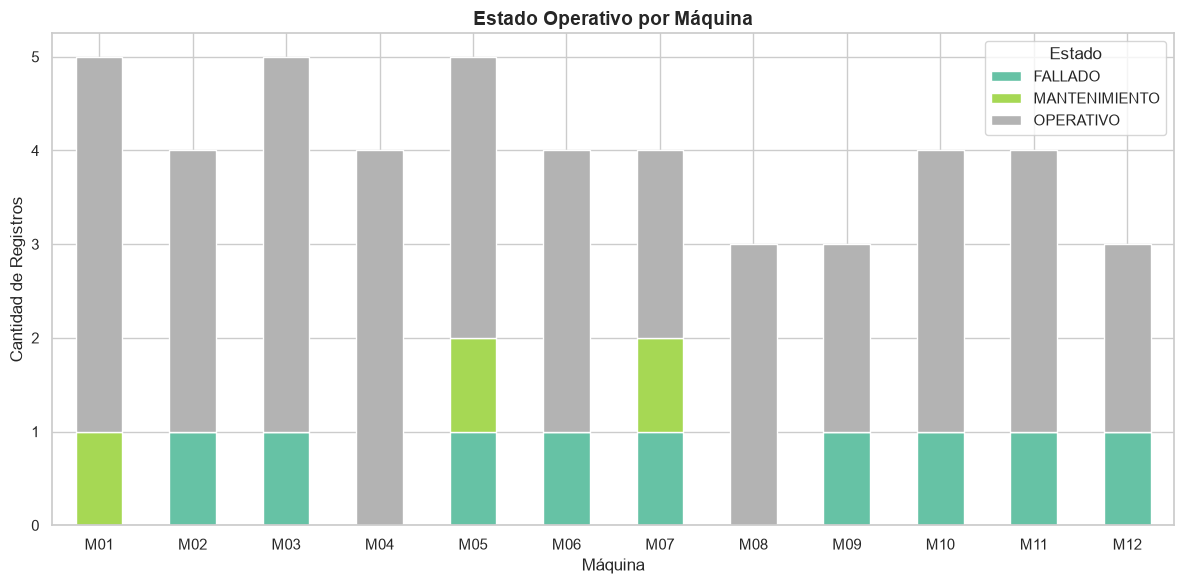

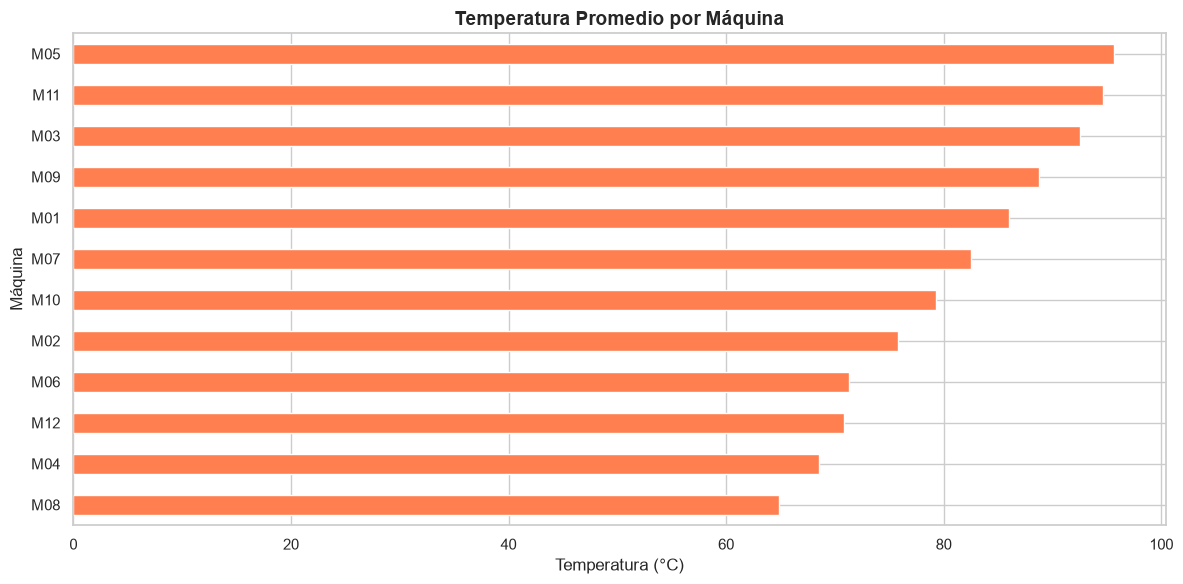

In [26]:
# Estado operativo por máquina
plt.figure(figsize=(12, 6))
estado_maquina = pd.crosstab(df_limpio['maquina_id'], df_limpio['estado_operativo'])
estado_maquina.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Estado Operativo por Máquina', fontsize=14, fontweight='bold')
plt.xlabel('Máquina')
plt.ylabel('Cantidad de Registros')
plt.xticks(rotation=0)
plt.legend(title='Estado')
plt.tight_layout()
plt.savefig('estado_por_maquina.png', dpi=150, bbox_inches='tight')
plt.show()

# Temperatura promedio por máquina
plt.figure(figsize=(12, 6))
temp_maquina = df_limpio.groupby('maquina_id')['temperatura_c'].mean().sort_values()
temp_maquina.plot(kind='barh', color='coral')
plt.title('Temperatura Promedio por Máquina', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Máquina')
plt.tight_layout()
plt.savefig('temp_por_maquina.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA - VIBRACIÓN VS FALLAS

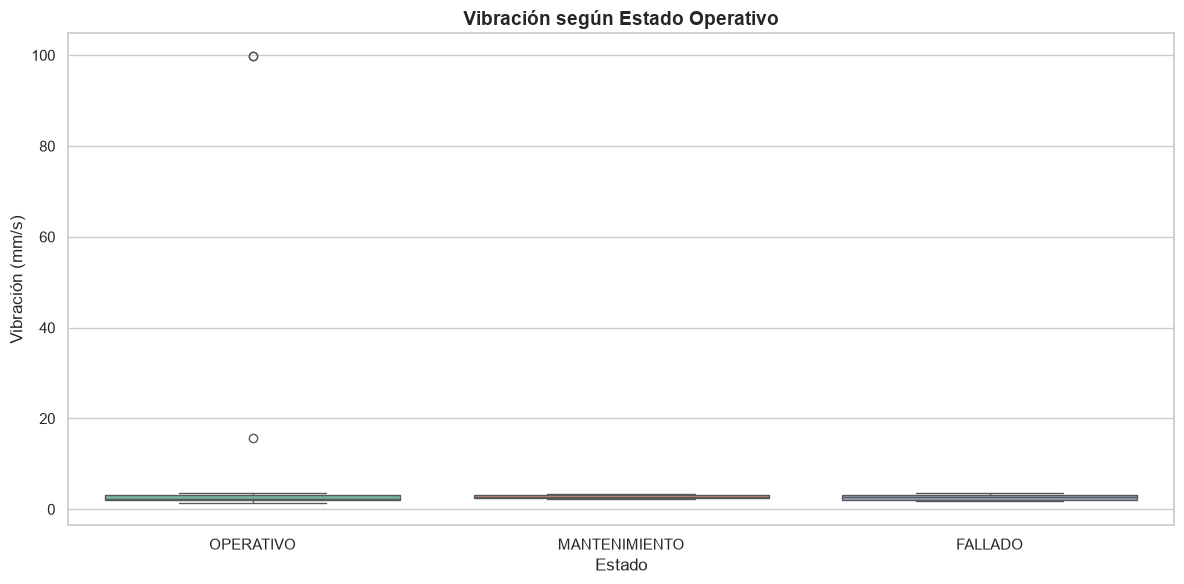


 Vibración promedio por estado:


,count,mean,std,min,25%,50%,75%,max
estado_operativo,,,,,,,,
FALLADO,9.0,2.666667,0.676387,1.9,2.000,2.80,3.20,3.6
MANTENIMIENTO,3.0,2.800000,0.556776,2.3,2.500,2.70,3.05,3.4
OPERATIVO,36.0,8.193056,22.678322,1.4,1.975,2.35,3.25,99.9


In [30]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_limpio, x='estado_operativo', y='vibracion_mm_s', palette='Set2')
plt.title('Vibración según Estado Operativo', fontsize=14, fontweight='bold')
plt.ylabel('Vibración (mm/s)')
plt.xlabel('Estado')
plt.tight_layout()
plt.savefig('vibracion_vs_estado.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Vibración promedio por estado:")
display(df_limpio.groupby('estado_operativo')['vibracion_mm_s'].describe())